# Round 3 results
After ProteinMPNN redesign from selected backbones

| Metric | Round1 | Round2 | Round2.5 | Round3 |
|---|---|---|---|---|
| Total designs | 2480 | 9520 | 59 | 2701 |
| ipAE < 5 | 2 (0.08%) | 88 (0.92%) | 22 (37.3%) | 98 (3.6%) |
| Pass all filters | 18 (0.73%) | 402 (4.2%) | 50 (87.4%) | 610 (22.6%) |
| Backbones with >=1 pass | 15/310 (4.8%) | 190/1190 (16.0%) | 50/59 (84.7%) | 610/2701 (22.6%) |

**What to do next**
With 610 passing designs:
1. Redo specificity scoring and compute AF3 stats
2. Combining passing designs from round 2, deep MPNN mining on top backbones — Running 32–50 sequences per backbone at T=0.1 and 0.2 on the top ~20–30 backbones (those with ≥3 passing sequences) would be the highest-yield next step.

## Calculate ipSAE

In [11]:
import sys
import glob
from pathlib import Path
from collections import OrderedDict
import pandas as pd
from scipy.stats import spearmanr

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
matplotlib.rcParams['figure.dpi'] = 120

# Add the directory containing pmhci_ipsae.py and pae_cutoff_analysis.py
# to the path. Edit this if your scripts are elsewhere.
SCRIPT_DIR = Path(".")   # <-- update if needed
sys.path.insert(0, str(SCRIPT_DIR))

from calc_ipsae import (
    load_pae_matrix, build_chain_slices,
    chain_lengths_from_pdb, score_binder_peptide_ipsae, print_summary,
)

print("Imports OK")

Imports OK


In [12]:
PAE_DIR  = Path("/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/pae")
PDB_DIR  = Path("/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/inputs/r3/threaded_pdbs")

NOMINAL_CUTOFF = 12.0   # Angstroms
DIST_CUTOFF    = 8.0    # Cα distance threshold for crystal contacts (Angstroms)
PEPTIDE_LEN = 9 # VVGADGVGK

In [13]:
# ── Discover design PAE + PDB pairs ─────────────────────────────────────────
npy_files = sorted(PAE_DIR.glob("*_pae.npy"))
pdb_files = []
for npy in npy_files:
    # Corresponding PDB: strip _pae.npy suffix, add .pdb
    stem = npy.stem.replace("_af2pred_pae", "")
    pdb  = PDB_DIR / f"{stem}.pdb"
    pdb_files.append(str(pdb) if pdb.exists() else None)

labels = [Path(n).stem.replace("_pae", "") for n in npy_files]

print(f"Found {len(npy_files)} PAE files")
print(f"  PDB matched: {sum(p is not None for p in pdb_files)} / {len(npy_files)}")
for npy, pdb, label in zip(npy_files, pdb_files, labels):
    pdb_ok = "✓" if pdb else "✗ (no PDB)"
    print(f"  {label:<50s} {pdb_ok}")

Found 2701 PAE files
  PDB matched: 2701 / 2701
  orient_252_pt20__31_pt12__0_a10_t0.1_s7_af2pred    ✓
  orient_252_pt20__31_pt12__0_a14_t0.15_s8_af2pred   ✓
  orient_252_pt20__31_pt12__0_a15_t0.15_s6_af2pred   ✓
  orient_252_pt20__31_pt12__0_a25_t0.2_s8_af2pred    ✓
  orient_252_pt20__31_pt12__0_a3_t0.1_s3_af2pred     ✓
  orient_252_pt20__31_pt12__0_a7_t0.1_s8_af2pred     ✓
  orient_252_pt20__31_pt12__0_a8_t0.1_s4_af2pred     ✓
  orient_252_pt20__31_pt12__0_a8_t0.1_s7_af2pred     ✓
  orient_252_pt20__31_pt12__14_a14_t0.15_s5_af2pred  ✓
  orient_252_pt20__31_pt12__14_a15_t0.15_s1_af2pred  ✓
  orient_252_pt20__31_pt12__14_a15_t0.15_s3_af2pred  ✓
  orient_252_pt20__31_pt12__14_a16_t0.15_s4_af2pred  ✓
  orient_252_pt20__31_pt12__14_a20_t0.15_s5_af2pred  ✓
  orient_252_pt20__31_pt12__14_a22_t0.2_s3_af2pred   ✓
  orient_252_pt20__31_pt12__14_a8_t0.1_s1_af2pred    ✓
  orient_252_pt20__31_pt12__14_a9_t0.1_s8_af2pred    ✓
  orient_252_pt20__31_pt12__16_a1_t0.1_s5_af2pred    ✓
  orient_252_pt20

In [14]:
# ── Quick ipSAE summary table at the nominal cutoff ─────────────────────────
print(f"{'Design':<50s} {'binder':>7} {'MHC':>5} {'pep':>4} {'ipSAE':>7} {'n_contacts':>11} {'mean_PAE':>9}")
print("─" * 100)

results_table = []
for npy, pdb, label in zip(npy_files, pdb_files, labels):
    try:
        cl = chain_lengths_from_pdb(pdb, peptide_length=PEPTIDE_LEN) if pdb else None
        if cl is None:
            print(f"  {label}: no PDB, skipping")
            continue
        r = score_binder_peptide_ipsae(str(npy), cl, pae_cutoff=NOMINAL_CUTOFF)
        results_table.append({"label": label, "chain_lengths": cl, **r})
        print(f"  {label:<48s} {cl['binder']:>7} {cl['MHC']:>5} {cl['peptide']:>4} "
              f"  {r['ipsae_binder_peptide']:>6.4f}  {r['n_contacts']:>10}  {r['mean_pae_bp']:>8.2f} Å")
    except Exception as e:
        print(f"  {label}: ERROR — {e}")

print(f"\nScored {len(results_table)} designs at PAE cutoff = {NOMINAL_CUTOFF} Å")

results_df = pd.DataFrame(results_table)

Design                                              binder   MHC  pep   ipSAE  n_contacts  mean_PAE
────────────────────────────────────────────────────────────────────────────────────────────────────
  orient_252_pt20__31_pt12__0_a10_t0.1_s7_af2pred       97   178    9   0.0000           0     22.10 Å
  orient_252_pt20__31_pt12__0_a14_t0.15_s8_af2pred      97   178    9   0.8607         853      4.20 Å
  orient_252_pt20__31_pt12__0_a15_t0.15_s6_af2pred      97   178    9   0.0000           0     20.35 Å
  orient_252_pt20__31_pt12__0_a25_t0.2_s8_af2pred       97   178    9   0.0000           0     22.40 Å
  orient_252_pt20__31_pt12__0_a3_t0.1_s3_af2pred        97   178    9   0.8721         868      3.76 Å
  orient_252_pt20__31_pt12__0_a7_t0.1_s8_af2pred        97   178    9   0.7129         843      6.61 Å
  orient_252_pt20__31_pt12__0_a8_t0.1_s4_af2pred        97   178    9   0.0000           0     21.56 Å
  orient_252_pt20__31_pt12__0_a8_t0.1_s7_af2pred        97   178    9   0.4528

  orient_252_pt20__31_pt12__73_a5_t0.1_s8_af2pred       97   178    9   0.0000           0     21.59 Å
  orient_252_pt20__31_pt12__73_a6_t0.1_s3_af2pred       97   178    9   0.0000           0     22.03 Å
  orient_252_pt20__31_pt12__73_a7_t0.1_s5_af2pred       97   178    9   0.0000           0     21.82 Å
  orient_252_pt20__31_pt12__73_a7_t0.1_s6_af2pred       97   178    9   0.0000           0     22.52 Å
  orient_252_pt20__31_pt12__73_a8_t0.1_s1_af2pred       97   178    9   0.0000           0     22.71 Å
  orient_252_pt20__31_pt12__91_a13_t0.15_s2_af2pred      97   178    9   0.0000           0     25.16 Å
  orient_252_pt20__31_pt12__91_a15_t0.15_s1_af2pred      97   178    9   0.3623         366     16.63 Å
  orient_252_pt20__31_pt12__91_a8_t0.1_s7_af2pred       97   178    9   0.0000           0     22.69 Å
  orient_252_pt20__31_pt12__97_a1_t0.1_s1_af2pred       97   178    9   0.8802         873      3.57 Å
  orient_252_pt20__31_pt12__97_a1_t0.1_s4_af2pred       97   178    9  

  orient_255_pt12__18_pt12__26_a1_t0.1_s7_af2pred       93   178    9   0.0000           0     23.08 Å
  orient_255_pt12__18_pt12__26_a2_t0.1_s1_af2pred       93   178    9   0.0000           0     22.97 Å
  orient_255_pt12__18_pt12__26_a2_t0.1_s4_af2pred       93   178    9   0.5739         693      9.15 Å
  orient_255_pt12__18_pt12__26_a3_t0.1_s5_af2pred       93   178    9   0.0000           0     22.70 Å
  orient_255_pt12__18_pt12__26_a3_t0.1_s7_af2pred       93   178    9   0.0000           0     23.27 Å
  orient_255_pt12__18_pt12__26_a3_t0.1_s8_af2pred       93   178    9   0.0000           0     23.39 Å
  orient_255_pt12__18_pt12__26_a4_t0.1_s1_af2pred       93   178    9   0.0000           0     23.93 Å
  orient_255_pt12__18_pt12__29_a11_t0.15_s4_af2pred      93   178    9   0.0000           0     22.16 Å
  orient_255_pt12__18_pt12__29_a13_t0.15_s2_af2pred      93   178    9   0.0019           2     20.11 Å
  orient_255_pt12__18_pt12__29_a20_t0.15_s3_af2pred      93   178    9 

  orient_255_pt12__18_pt12__53_a2_t0.1_s4_af2pred       93   178    9   0.0000           0     22.64 Å
  orient_255_pt12__18_pt12__53_a2_t0.1_s5_af2pred       93   178    9   0.0019           6     20.01 Å
  orient_255_pt12__18_pt12__54_a1_t0.1_s1_af2pred       93   178    9   0.0019           2     20.10 Å
  orient_255_pt12__18_pt12__54_a1_t0.1_s2_af2pred       93   178    9   0.0000           0     21.26 Å
  orient_255_pt12__18_pt12__54_a1_t0.1_s4_af2pred       93   178    9   0.4307         480     11.65 Å
  orient_255_pt12__18_pt12__54_a1_t0.1_s8_af2pred       93   178    9   0.1741         154     15.36 Å
  orient_255_pt12__18_pt12__54_a2_t0.1_s1_af2pred       93   178    9   0.0000           0     22.22 Å
  orient_255_pt12__18_pt12__54_a2_t0.1_s2_af2pred       93   178    9   0.0018           2     19.97 Å
  orient_255_pt12__18_pt12__54_a2_t0.1_s6_af2pred       93   178    9   0.6531         773      7.55 Å
  orient_255_pt12__18_pt12__54_a2_t0.1_s8_af2pred       93   178    9   0

  orient_255_pt12__18_pt12__86_a2_t0.1_s1_af2pred       93   178    9   0.0000           0     21.32 Å
  orient_255_pt12__18_pt12__89_a1_t0.1_s3_af2pred       93   178    9   0.0000           0     22.31 Å
  orient_255_pt12__18_pt12__89_a1_t0.1_s4_af2pred       93   178    9   0.0000           0     22.45 Å
  orient_255_pt12__18_pt12__89_a1_t0.1_s5_af2pred       93   178    9   0.0000           0     21.82 Å
  orient_255_pt12__18_pt12__89_a1_t0.1_s7_af2pred       93   178    9   0.0000           0     24.83 Å
  orient_255_pt12__18_pt12__89_a1_t0.1_s8_af2pred       93   178    9   0.0000           0     24.48 Å
  orient_255_pt12__18_pt12__89_a2_t0.1_s1_af2pred       93   178    9   0.0000           0     24.38 Å
  orient_255_pt12__18_pt12__89_a2_t0.1_s2_af2pred       93   178    9   0.0000           0     22.99 Å
  orient_255_pt12__18_pt12__89_a2_t0.1_s4_af2pred       93   178    9   0.0000           0     22.93 Å
  orient_255_pt12__18_pt12__8_a1_t0.1_s1_af2pred        93   178    9   0

...

  orient_255_pt12__70_pt12__97_a1_t0.1_s4_af2pred       93   178    9   0.0000           0     21.51 Å
  orient_255_pt12__70_pt12__97_a3_t0.1_s2_af2pred       93   178    9   0.7072         801      6.69 Å
  orient_255_pt12__70_pt12__97_a3_t0.1_s5_af2pred       93   178    9   0.7953         814      5.21 Å
  orient_255_pt12__70_pt12__97_a3_t0.1_s6_af2pred       93   178    9   0.8050         817      5.01 Å
  orient_255_pt12__70_pt12__97_a3_t0.1_s7_af2pred       93   178    9   0.0000           0     22.63 Å
  orient_255_pt12__70_pt12__97_a3_t0.1_s8_af2pred       93   178    9   0.6086         737      8.55 Å
  orient_255_pt12__70_pt12__97_a4_t0.1_s4_af2pred       93   178    9   0.8111         813      5.00 Å
  orient_255_pt12__8_pt25__10_a1_t0.1_s3_af2pred        93   178    9   0.0018           3     20.48 Å
  orient_255_pt12__8_pt25__10_a1_t0.1_s4_af2pred        93   178    9   0.0000           0     25.34 Å
  orient_255_pt12__8_pt25__10_a2_t0.1_s2_af2pred        93   178    9   0

  orient_255_pt12__8_pt25__30_a6_t0.1_s8_af2pred        93   178    9   0.0000           0     23.35 Å
  orient_255_pt12__8_pt25__30_a7_t0.1_s5_af2pred        93   178    9   0.7306         794      6.34 Å
  orient_255_pt12__8_pt25__30_a8_t0.1_s1_af2pred        93   178    9   0.0000           0     22.88 Å
  orient_255_pt12__8_pt25__30_a9_t0.1_s3_af2pred        93   178    9   0.7397         795      6.18 Å
  orient_255_pt12__8_pt25__31_a1_t0.1_s1_af2pred        93   178    9   0.0000           0     24.26 Å
  orient_255_pt12__8_pt25__31_a1_t0.1_s2_af2pred        93   178    9   0.0065          25     17.71 Å
  orient_255_pt12__8_pt25__31_a1_t0.1_s4_af2pred        93   178    9   0.0000           0     23.07 Å
  orient_255_pt12__8_pt25__31_a1_t0.1_s7_af2pred        93   178    9   0.0000           0     23.29 Å
  orient_255_pt12__8_pt25__31_a2_t0.1_s1_af2pred        93   178    9   0.0000           0     23.14 Å
  orient_255_pt12__8_pt25__31_a2_t0.1_s3_af2pred        93   178    9   0

  orient_255_pt12__8_pt25__49_a1_t0.1_s4_af2pred        93   178    9   0.0000           0     22.45 Å
  orient_255_pt12__8_pt25__49_a2_t0.1_s1_af2pred        93   178    9   0.0355          44     16.45 Å
  orient_255_pt12__8_pt25__49_a2_t0.1_s2_af2pred        93   178    9   0.3386         331     12.90 Å
  orient_255_pt12__8_pt25__49_a2_t0.1_s3_af2pred        93   178    9   0.0000           0     23.25 Å
  orient_255_pt12__8_pt25__49_a2_t0.1_s4_af2pred        93   178    9   0.0000           0     23.76 Å
  orient_255_pt12__8_pt25__49_a2_t0.1_s6_af2pred        93   178    9   0.0000           0     22.44 Å
  orient_255_pt12__8_pt25__49_a2_t0.1_s7_af2pred        93   178    9   0.0000           0     22.70 Å
  orient_255_pt12__8_pt25__4_a15_t0.15_s4_af2pred       93   178    9   0.5638         693      9.40 Å
  orient_255_pt12__8_pt25__4_a16_t0.15_s3_af2pred       93   178    9   0.0020           1     21.67 Å
  orient_255_pt12__8_pt25__4_a17_t0.15_s1_af2pred       93   178    9   0

  orient_255_pt12__91_pt25__29_a7_t0.1_s8_af2pred       93   178    9   0.0000           0     22.97 Å
  orient_255_pt12__91_pt25__29_a9_t0.1_s2_af2pred       93   178    9   0.0000           0     23.41 Å
  orient_255_pt12__91_pt25__29_a9_t0.1_s3_af2pred       93   178    9   0.0000           0     22.05 Å
  orient_255_pt12__91_pt25__33_a2_t0.1_s3_af2pred       93   178    9   0.0000           0     25.09 Å
  orient_255_pt12__91_pt25__33_a3_t0.1_s3_af2pred       93   178    9   0.0000           0     22.60 Å
  orient_255_pt12__91_pt25__33_a3_t0.1_s4_af2pred       93   178    9   0.0000           0     23.03 Å
  orient_255_pt12__91_pt25__33_a3_t0.1_s7_af2pred       93   178    9   0.0020          11     18.45 Å
  orient_255_pt12__91_pt25__33_a4_t0.1_s2_af2pred       93   178    9   0.0000           0     25.34 Å
  orient_255_pt12__91_pt25__33_a4_t0.1_s6_af2pred       93   178    9   0.0000           0     24.05 Å
  orient_255_pt12__91_pt25__33_a5_t0.1_s1_af2pred       93   178    9   0

  orient_255_pt12__91_pt25__49_a1_t0.1_s7_af2pred       93   178    9   0.0000           0     23.20 Å
  orient_255_pt12__91_pt25__49_a2_t0.1_s2_af2pred       93   178    9   0.0000           0     23.16 Å
  orient_255_pt12__91_pt25__49_a2_t0.1_s3_af2pred       93   178    9   0.0000           0     22.85 Å
  orient_255_pt12__91_pt25__8_a11_t0.15_s4_af2pred      93   178    9   0.0000           0     22.39 Å
  orient_255_pt12__91_pt25__8_a22_t0.2_s3_af2pred       93   178    9   0.0020           3     20.06 Å
  orient_255_pt12__91_pt25__8_a23_t0.2_s2_af2pred       93   178    9   0.0000           0     22.32 Å
  orient_255_pt12__91_pt25__8_a24_t0.2_s5_af2pred       93   178    9   0.0000           0     22.62 Å
  orient_255_pt12__91_pt25__8_a25_t0.2_s6_af2pred       93   178    9   0.0017           1     21.11 Å
  orient_255_pt12__91_pt25__8_a26_t0.2_s2_af2pred       93   178    9   0.0000           0     21.96 Å
  orient_255_pt12__91_pt25__8_a28_t0.2_s3_af2pred       93   178    9   0

In [15]:
results_df[results_df['n_contacts']>0].sort_values(by='ipsae_binder_peptide', ascending=False)

,label,chain_lengths,ipsae_binder_peptide,ipsae_bp,ipsae_pb,n_contacts,d0,mean_pae_bp,mean_pae_contact
1431,orient_255_pt12__33_pt12__81_a4_t0.1_s5_af2pred,"{'binder': 93, 'MHC': 178, 'peptide': 9}",0.8959,0.8959,0.6658,824,9.754,3.421,3.204
1414,orient_255_pt12__33_pt12__7_a4_t0.1_s4_af2pred,"{'binder': 93, 'MHC': 178, 'peptide': 9}",0.8940,0.8940,0.7512,820,9.735,3.523,3.207
28,orient_252_pt20__31_pt12__27_a7_t0.1_s4_af2pred,"{'binder': 97, 'MHC': 178, 'peptide': 9}",0.8846,0.8846,0.6154,860,9.923,3.645,3.471
2019,orient_255_pt12__70_pt12__37_a1_t0.1_s8_af2pred,"{'binder': 93, 'MHC': 178, 'peptide': 9}",0.8846,0.8846,0.6648,837,9.816,3.435,3.435
1256,orient_255_pt12__33_pt12__26_a28_t0.2_s6_af2pred,"{'binder': 93, 'MHC': 178, 'peptide': 9}",0.8833,0.8833,0.6840,826,9.764,3.575,3.431
1412,orient_255_pt12__33_pt12__7_a2_t0.1_s1_af2pred,"{'binder': 93, 'MHC': 178, 'peptide': 9}",0.8831,0.8831,0.6908,836,9.811,3.452,3.442
1372,orient_255_pt12__33_pt12__67_a3_t0.1_s8_af2pred,"{'binder': 93, 'MHC': 178, 'peptide': 9}",0.8818,0.8818,0.6824,834,9.802,3.517,3.484
25,orient_252_pt20__31_pt12__27_a2_t0.1_s1_af2pred,"{'binder': 97, 'MHC': 178, 'peptide': 9}",0.8813,0.8813,0.6475,870,9.969,3.592,3.558
91,orient_252_pt20__31_pt12__97_a1_t0.1_s1_af2pred,"{'binder': 97, 'MHC': 178, 'peptide': 9}",0.8802,0.8802,0.6231,873,9.983,3.569,3.569
2056,orient_255_pt12__70_pt12__46_a1_t0.1_s2_af2pred,"{'binder': 93, 'MHC': 178, 'peptide': 9}",0.8784,0.8784,0.6938,816,9.716,3.869,3.501


In [6]:
len(results_df[results_df['n_contacts']>0].sort_values(by='ipsae_binder_peptide', ascending=False))

1281

In [16]:
ipae_df = pd.read_csv('/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras_all_scores.csv')
merged_df = pd.merge(results_df[results_df['n_contacts']>0], ipae_df, how='left', left_on='label', right_on='description')
merged_df = merged_df[['label', 'ipsae_binder_peptide', 'ipsae_bp', 'ipsae_pb', 'n_contacts', 'd0', 'mean_pae_bp', 'mean_pae_contact', 'binder_aligned_rmsd', 'target_aligned_rmsd', 'pae_interaction', 'plddt_binder', 'plddt_target']]
pd.set_option('display.max_rows', None)
merged_df[merged_df['pae_interaction']<5].sort_values(by='ipsae_binder_peptide', ascending=False)

,label,ipsae_binder_peptide,ipsae_bp,ipsae_pb,n_contacts,d0,mean_pae_bp,mean_pae_contact,binder_aligned_rmsd,target_aligned_rmsd,pae_interaction,plddt_binder,plddt_target
770,orient_255_pt12__33_pt12__81_a4_t0.1_s5_af2pred,0.8959,0.8959,0.6658,824,9.754,3.421,3.204,0.357,1.511,3.859,95.889,95.594
755,orient_255_pt12__33_pt12__7_a4_t0.1_s4_af2pred,0.8940,0.8940,0.7512,820,9.735,3.523,3.207,0.700,1.556,4.085,94.430,95.992
15,orient_252_pt20__31_pt12__27_a7_t0.1_s4_af2pred,0.8846,0.8846,0.6154,860,9.923,3.645,3.471,0.602,0.782,3.982,95.205,95.177
1035,orient_255_pt12__70_pt12__37_a1_t0.1_s8_af2pred,0.8846,0.8846,0.6648,837,9.816,3.435,3.435,0.511,1.480,4.026,95.579,95.413
660,orient_255_pt12__33_pt12__26_a28_t0.2_s6_af2pred,0.8833,0.8833,0.6840,826,9.764,3.575,3.431,0.555,2.287,4.255,94.835,95.378
753,orient_255_pt12__33_pt12__7_a2_t0.1_s1_af2pred,0.8831,0.8831,0.6908,836,9.811,3.452,3.442,0.689,1.596,4.168,95.332,95.631
732,orient_255_pt12__33_pt12__67_a3_t0.1_s8_af2pred,0.8818,0.8818,0.6824,834,9.802,3.517,3.484,0.631,1.339,4.150,94.830,95.453
13,orient_252_pt20__31_pt12__27_a2_t0.1_s1_af2pred,0.8813,0.8813,0.6475,870,9.969,3.592,3.558,0.562,1.230,4.212,94.756,95.167
32,orient_252_pt20__31_pt12__97_a1_t0.1_s1_af2pred,0.8802,0.8802,0.6231,873,9.983,3.569,3.569,0.494,0.835,4.073,94.890,94.950
1059,orient_255_pt12__70_pt12__46_a1_t0.1_s2_af2pred,0.8784,0.8784,0.6938,816,9.716,3.869,3.501,0.753,1.214,4.436,94.216,95.369


In [8]:
merged_df.to_csv('/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_ipae_ipsae_scores.csv')

In [10]:
len(merged_df[merged_df['ipsae_binder_peptide']>=0.8])

205

Spearman: -0.8502124251455511, p_value=1.7828121174465713e-58


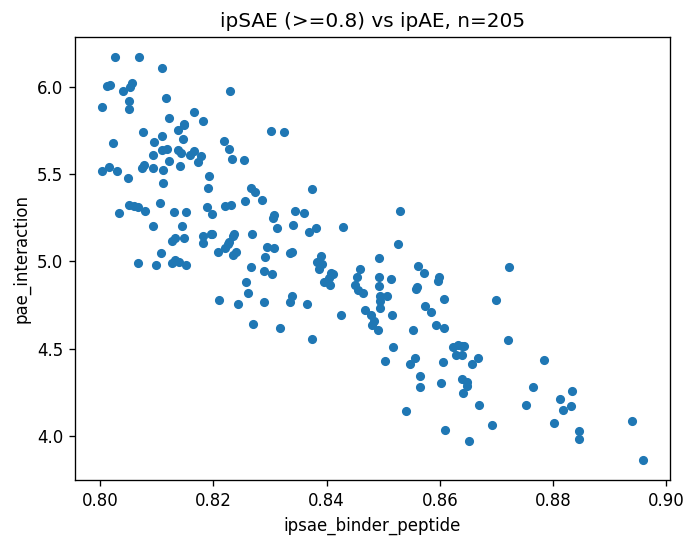

In [17]:
filtered_merged_df = merged_df[merged_df['ipsae_binder_peptide']>=0.8]
rho, p_value = spearmanr(filtered_merged_df['ipsae_binder_peptide'], filtered_merged_df['pae_interaction'])
print(f"Spearman: {rho}, p_value={p_value}")
filtered_merged_df.plot.scatter(x='ipsae_binder_peptide', y='pae_interaction', title=f"ipSAE (>=0.8) vs ipAE, n={len(filtered_merged_df)}")
plt.show()

### Manually checked sequences of all ipSAE >= 0.8:

In [22]:
!/n/groups/marks/users/aaron/pmhc/envs/dl_binder_design/bin/python extract_passing_seqs.py \
    --scores /n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_ipae_ipsae_scores.csv \
    --fasta  /n/groups/marks/users/aaron/pmhc_cp/proteinmpnn/outputs/kras_r3/all_sequences.fa \
    --output /n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/passing_ipsae0.8.fa \
    --ipsae_cutoff 0.8

Total scored designs:  1281
Passing ipsae >= 0.8: 205

Extracted:  205 sequences -> /n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/passing_ipsae0.8.fa


In [25]:
!/n/groups/marks/users/aaron/pmhc/envs/dl_binder_design/bin/python analyze_top_sequences.py \
    --fasta /n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/passing_ipsae0.8.fa \
    --output /n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/sequence_qc.tsv

Total sequences: 205

Sequence QC summary (n=205)
  Length range:       93–97 aa
  Charge range:       -16.0 to -3.0
  Charge mean:        -6.0

  Flag counts:
    Charge > -3.0:    0
    Charge -3.0:      26  (borderline)
    Any Cys:          0
    Met >= 3:         15
    Met == 2:         33  (acceptable)
    Met == 1:         95  (acceptable)
    Any Trp:          73
    Clean (OK):       120

Charge distribution
charge
-16.0     1
-14.0     1
-12.0     3
-11.0     4
-10.0     6
-9.9      1
-9.8      1
-9.0      9
-8.9      1
-8.0     11
-7.9      4
-7.0     34
-6.9      4
-6.8      2
-6.0     20
-5.9      6
-5.8      2
-5.0     22
-4.9      8
-4.8      1
-4.0     30
-3.9      6
-3.8      2
-3.0     26

Flagged sequences
  orient_255_pt12__18_pt12__40_a2_t0.1_s1                      chg= -3.0  M=4  W=1  C=0  [MET_HIGH|TRP]
  orient_255_pt12__18_pt12__12_a4_t0.1_s6                      chg= -3.0  M=1  W=1  C=0  [TRP]
  orient_255_pt12__18_pt12__84_a2_t0.1_s1                      ch

Here's the breakdown

**What looks good**

Zero cysteines across all sequences — clean. Charge is net negative throughout (−3 to −16), consistent with the Liu et al. target range of ≤ −3. Length is uniform at 93–97 residues per backbone family, suggesting proper threading. Composition is heavily E/A/K/R/L-dominated, matching the reference designs well.

**What to flag**

**Met >= 3 (15 sequences):** The `_pt12__72` backbone family is the main offender — `a1`, `a5`, `a8`, `a10` all carry 2 Met, and `a5` has 3. The `_pt12__18` family also has several with 2–4 Met (`a40` has 4 Met). Oxidation-sensitive; flag for ProteinMPNN redesign with `--omit_AAs CM` if not already applied, or deprioritise. Single Met (present in ~10 others) is borderline acceptable. **This will be an issue if these are at the interface. Same for Lys**

**Trp > 0 (73 sequences):** Trp isn't explicitly excluded in Liu et al., but it's rare in the published designs (~0 in most), because it can introduce high surface hydrophobicity. The `_pt12__72_a5` and `_pt12__18_a40` designs have both high Met and Trp — deprioritise these two. Isolated single Trp (e.g. `_pt12__16_a5`, `_pt12__18_a84`) is lower concern but worth noting. **See if they are on the surface**

**Borderline charge (−3.0 exactly):** `orient_252_pt20__31_pt12__0_a3` sits exactly at the −3.0 cutoff. Technically passing but marginal — low priority.

**`_pt12__40_a2`:** 4 Met + 1 Trp at charge −3.0 — worst combination in the set (and there are others), deprioritize entirely.

**What to do next**

Run the full set through `charge_cysteine_audit.py` to get `interface_fixed_resnums` for the high-Met designs, then ProteinMPNN redesign with `--omit_AAs CM` targeting those residues. The clean sequences (low Met/Trp) — primarily the `_pt12__27`, `_pt12__97`, `_pt12__53`, and `_pt12__18_a12/a25/a9` families (and so on) — are ready to go straight to pMHC fold and specificity filtering.

### Save passing pdbs for downstream specificity screens

In [18]:
import os
from analyze_af2_scores import extract_top_pdbs
os.environ['PATH'] += os.pathsep + '/n/groups/marks/users/aaron/pmhc/silent_tools'
import pyrosetta
from pyrosetta import *
init("-mute all -ignore_unrecognized_res true")

┌───────────────────────────────────────────────────────────────────────────────┐
│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python311.ubuntu 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org


In [19]:
merged_df = pd.read_csv('/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_ipae_ipsae_scores.csv')
merged_df.head()
merged_df.rename(columns={'label': 'description'}, inplace=True)
top=merged_df[merged_df['ipsae_binder_peptide']>=0.8]
extract_top_pdbs(top, silent_dir='/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras', out_dir='/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/top_pdbs')

205

Extracting 205 PDBs from silent files
  af2_kras_predictions_0.silent: extracting 22 tag(s)
core.init: Rosetta version: PyRosetta4.Release.python311.ubuntu r1 2026.03+releasequarterly.5e498f1409 5e498f1409c68ade56c8ce5842bf79e1b02e8db4 http://www.pyrosetta.org 2026-01-13T13:24:11
core.init: Rosetta extras: []
core.init: command: PyRosetta -in:file:silent tmp_tPOvs1UuzwS7k.silent -in:file:silent_struct_type binary -database /n/groups/marks/users/aaron/pmhc/envs/dl_binder_design/lib/python3.11/site-packages/pyrosetta/database
basic.random.init_random_generator: 'RNG device' seed mode, using '/dev/urandom', seed=-450745153 seed_offset=0 real_seed=-450745153
basic.random.init_random_generator: RandomGenerator:init: Normal mode, seed=-450745153 RG_type=mt19937
core.io.silent.SilentFileData: Reading all structures from tmp_tPOvs1UuzwS7k.silent
core.io.silent.SilentFileData: Finished reading 22 structures from tmp_tPOvs1UuzwS7k.silent
core.chemical.GlobalResidueTypeSet: Finished initiali

core.init: Rosetta version: PyRosetta4.Release.python311.ubuntu r1 2026.03+releasequarterly.5e498f1409 5e498f1409c68ade56c8ce5842bf79e1b02e8db4 http://www.pyrosetta.org 2026-01-13T13:24:11
core.init: Rosetta extras: []
core.init: command: PyRosetta -in:file:silent tmp_7vwrkygqR2KbG.silent -in:file:silent_struct_type binary -database /n/groups/marks/users/aaron/pmhc/envs/dl_binder_design/lib/python3.11/site-packages/pyrosetta/database
basic.random.init_random_generator: 'RNG device' seed mode, using '/dev/urandom', seed=-1602908402 seed_offset=0 real_seed=-1602908402
basic.random.init_random_generator: RandomGenerator:init: Normal mode, seed=-1602908402 RG_type=mt19937
core.io.silent.SilentFileData: Reading all structures from tmp_7vwrkygqR2KbG.silent
core.io.silent.SilentFileData: Finished reading 29 structures from tmp_7vwrkygqR2KbG.silent
core.chemical.GlobalResidueTypeSet: Finished initializing fa_standard residue type set.  Created 985 residue types
core.chemical.GlobalResidueTypeS

│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python311.ubuntu 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags 
core.init: Rosetta version: PyRosetta4.Release.python311.ubuntu r1 2026.03+releasequarterly.5e498f1409 5e498f1409c68ade56c8ce5842bf79e1b02e8db4 http://www.pyrosetta.org 2

│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python311.ubuntu 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags 
core.init: Rosetta version: PyRosetta4.Release.python311.ubuntu r1 2026.03+releasequarterly.5e498f1409 5e498f1409c68ade56c8ce5842bf79e1b02e8db4 http://www.pyrosetta.org 2

core.init: Rosetta version: PyRosetta4.Release.python311.ubuntu r1 2026.03+releasequarterly.5e498f1409 5e498f1409c68ade56c8ce5842bf79e1b02e8db4 http://www.pyrosetta.org 2026-01-13T13:24:11
core.init: Rosetta extras: []
core.init: command: PyRosetta -in:file:silent tmp_xzyEoZ7R4a7hC.silent -in:file:silent_struct_type binary -database /n/groups/marks/users/aaron/pmhc/envs/dl_binder_design/lib/python3.11/site-packages/pyrosetta/database
basic.random.init_random_generator: 'RNG device' seed mode, using '/dev/urandom', seed=777389135 seed_offset=0 real_seed=777389135
basic.random.init_random_generator: RandomGenerator:init: Normal mode, seed=777389135 RG_type=mt19937
core.io.silent.SilentFileData: Reading all structures from tmp_xzyEoZ7R4a7hC.silent
core.io.silent.SilentFileData: Finished reading 34 structures from tmp_xzyEoZ7R4a7hC.silent
core.chemical.GlobalResidueTypeSet: Finished initializing fa_standard residue type set.  Created 985 residue types
core.chemical.GlobalResidueTypeSet: To

│                                  PyRosetta-4                                  │
│               Created in JHU by Sergey Lyskov and PyRosetta Team              │
│               (C) Copyright Rosetta Commons Member Institutions               │
│                                                                               │
│ NOTE: USE OF PyRosetta FOR COMMERCIAL PURPOSES REQUIRES PURCHASE OF A LICENSE │
│          See LICENSE.PyRosetta.md or email license@uw.edu for details         │
└───────────────────────────────────────────────────────────────────────────────┘
PyRosetta-4 2026 [Rosetta PyRosetta4.Release.python311.ubuntu 2026.03+releasequarterly.5e498f1409c68ade56c8ce5842bf79e1b02e8db4 2026-01-13T13:24:11] retrieved from: http://www.pyrosetta.org
core.init: Checking for fconfig files in pwd and ./rosetta/flags 
core.init: Rosetta version: PyRosetta4.Release.python311.ubuntu r1 2026.03+releasequarterly.5e498f1409 5e498f1409c68ade56c8ce5842bf79e1b02e8db4 http://www.pyrosetta.org 2

['/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/top_pdbs/orient_252_pt20__31_pt12__0_a14_t0.15_s8_af2pred.pdb',
 '/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/top_pdbs/orient_252_pt20__31_pt12__0_a3_t0.1_s3_af2pred.pdb',
 '/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/top_pdbs/orient_252_pt20__31_pt12__16_a1_t0.1_s5_af2pred.pdb',
 '/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/top_pdbs/orient_252_pt20__31_pt12__16_a5_t0.1_s2_af2pred.pdb',
 '/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/top_pdbs/orient_252_pt20__31_pt12__27_a2_t0.1_s1_af2pred.pdb',
 '/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/top_pdbs/orient_252_pt20__31_pt12__27_a7_t0.1_s4_af2pred.pdb',
 '/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/outputs/r3/af2_kras/top_pdbs/orient_252_pt20__31_pt12__53_a1_t0.1_s3_af2pred.pdb',
 '/n/groups/marks/users/aaron/pmhc_cp/af_init_guess/out